# MWE: how well does AMI-like imaging recover known scenes?

An image reconstruction is only as trustworthy as its performance on simulated data with known answers. This notebook runs that test for three truth scenes, each three to four beams across: a dusty spiral whose windings are more than a beam apart, an inclined lopsided ring, and an extended core with a compact clump about 1.5 beams away, each next to an analytic star, on simulated AMI-like data from `virgil.coverage.ami_grid_record`: information confined to the mask's splodges and compressed into modes that are blind to flux and position. The signal-to-noise ratio is varied through the flux of the extended emission (10%, 3% and 1% of the star's) at fixed errors. Every image is reconstructed with maximum entropy, with its weight chosen from an L-curve by the discrepancy principle (χ² per data point equal to one).

You should come away with a feel for what AMI imaging can and cannot recover, and a template for testing a reconstruction set-up on your own coverage before trusting it on real data.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from virgil.coverage import ami_grid_record
from virgil.imaging import (
    MaxEntropy,
    beam,
    field_of_view,
    image_priors,
    l_curve,
)
from virgil.models import GaussianDisk, Image, PointSource, System
from virgil.oidata import OIData
from virgil.plotting import plot_model, plot_residual_map
from virgil.scenes import gaussian_blob, ring, spiral

template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
scale = 20.0
npix = round(
    field_of_view(template, largest_mas=1250.0) / scale
)  # ~8 beams across
fov = npix * scale
scenes = {
    "spiral": spiral(
        npix, scale, step_mas=250.0, width_mas=40.0, turns=1.5, fade_mas=500.0
    ),
    "ring": ring(
        npix,
        scale,
        240.0,
        36.0,
        inc_deg=50.0,
        pa_deg=30.0,
        asymmetry=0.5,
        asymmetry_pa_deg=90.0,
    ),
    "core + clump": 0.7 * gaussian_blob(npix, scale, 90.0)
    + 0.3 * gaussian_blob(npix, scale, 25.0, dra=-180.0, ddec=150.0),
}
fluxes = [0.1, 0.03, 0.01]
resolution = beam(template)
print(
    f"{len(scenes)} scenes x {len(fluxes)} fluxes; {npix}² pixels of {scale} mas; beam {resolution.major_mas:.0f} x {resolution.minor_mas:.0f} mas"
)

3 scenes x 3 fluxes; 62² pixels of 20.0 mas; beam 154 x 131 mas


## Reconstructing every case

For each scene and flux, the data are simulated with a fixed seed, and a maximum-entropy L-curve over nine weights is fitted from a blurred Gaussian start, keeping the image whose χ² per point first reaches one. The flux of the extended emission is held at its true value, so the test is of the image's shape. The loop takes a few minutes.

In [2]:
def ncc(a, b):
    a, b = a - a.mean(), b - b.mean()
    return float(jnp.sum(a * b) / jnp.sqrt(jnp.sum(a * a) * jnp.sum(b * b)))


recovered, curves = {}, {}
for (name, truth_image), flux in tqdm(
    [(s, f) for s in scenes.items() for f in fluxes]
):
    truth = System(
        star=PointSource(),
        env=Image.from_brightness(truth_image, scale, flux=flux),
    )
    data = template.with_model(truth, key=jax.random.PRNGKey(0))
    start = System(
        star=PointSource(),
        env=Image.from_model(GaussianDisk(180.0), npix, scale, flux=flux),
    )
    curve = l_curve(
        start,
        image_priors(start),
        data,
        MaxEntropy(1.0, path="env"),
        jnp.logspace(-1, 4, 9),
    )
    weight = curve.discrepancy() or curve.corner()
    best = int(jnp.argmin(jnp.abs(jnp.log(curve.weights) - jnp.log(weight))))
    image = curve.results[best].model.env
    recovered[name, flux] = (
        image,
        ncc(image.brightness, truth_image),
        float(curve.weights[best]),
    )
    curves[name, flux] = curve
print("normalised cross-correlation with the truth (weight chosen):")
for name in scenes:
    print(
        f"  {name:>13}: "
        + "  ".join(
            f"{f:.0%}: {recovered[name, f][1]:.3f} (w={recovered[name, f][2]:.2g})"
            for f in fluxes
        )
    )

  0%|          | 0/9 [00:00<?, ?it/s]

W1001 12:49:14.952849 10452189 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/Users/benpope/code/virgil/src/virgil/imaging.py:470: RuntimeWarning: fit(method='lbfgs') did not converge in 20000 steps.
  result = fit(


normalised cross-correlation with the truth (weight chosen):
         spiral: 10%: 0.963 (w=5.6e+02)  3%: 0.914 (w=1.3e+02)  1%: 0.746 (w=1.3e+02)
           ring: 10%: 0.996 (w=5.6e+02)  3%: 0.985 (w=1.3e+02)  1%: 0.938 (w=32)
   core + clump: 10%: 0.991 (w=1.3e+02)  3%: 0.980 (w=1.3e+02)  1%: 0.937 (w=32)


## The reconstructions

Each row is one scene: the truth, then its reconstructions from the brightest to the faintest extended emission, with the beam shaded in the lower left. With the scenes three to four beams across, all three are recovered well at 10% and 3% of the star's flux: the spiral's windings, the ring's hole and brighter eastern side, and the clump, cleanly separated from the core. At 1% the ring and the clump survive, while the spiral's windings break up into noise-driven knots.

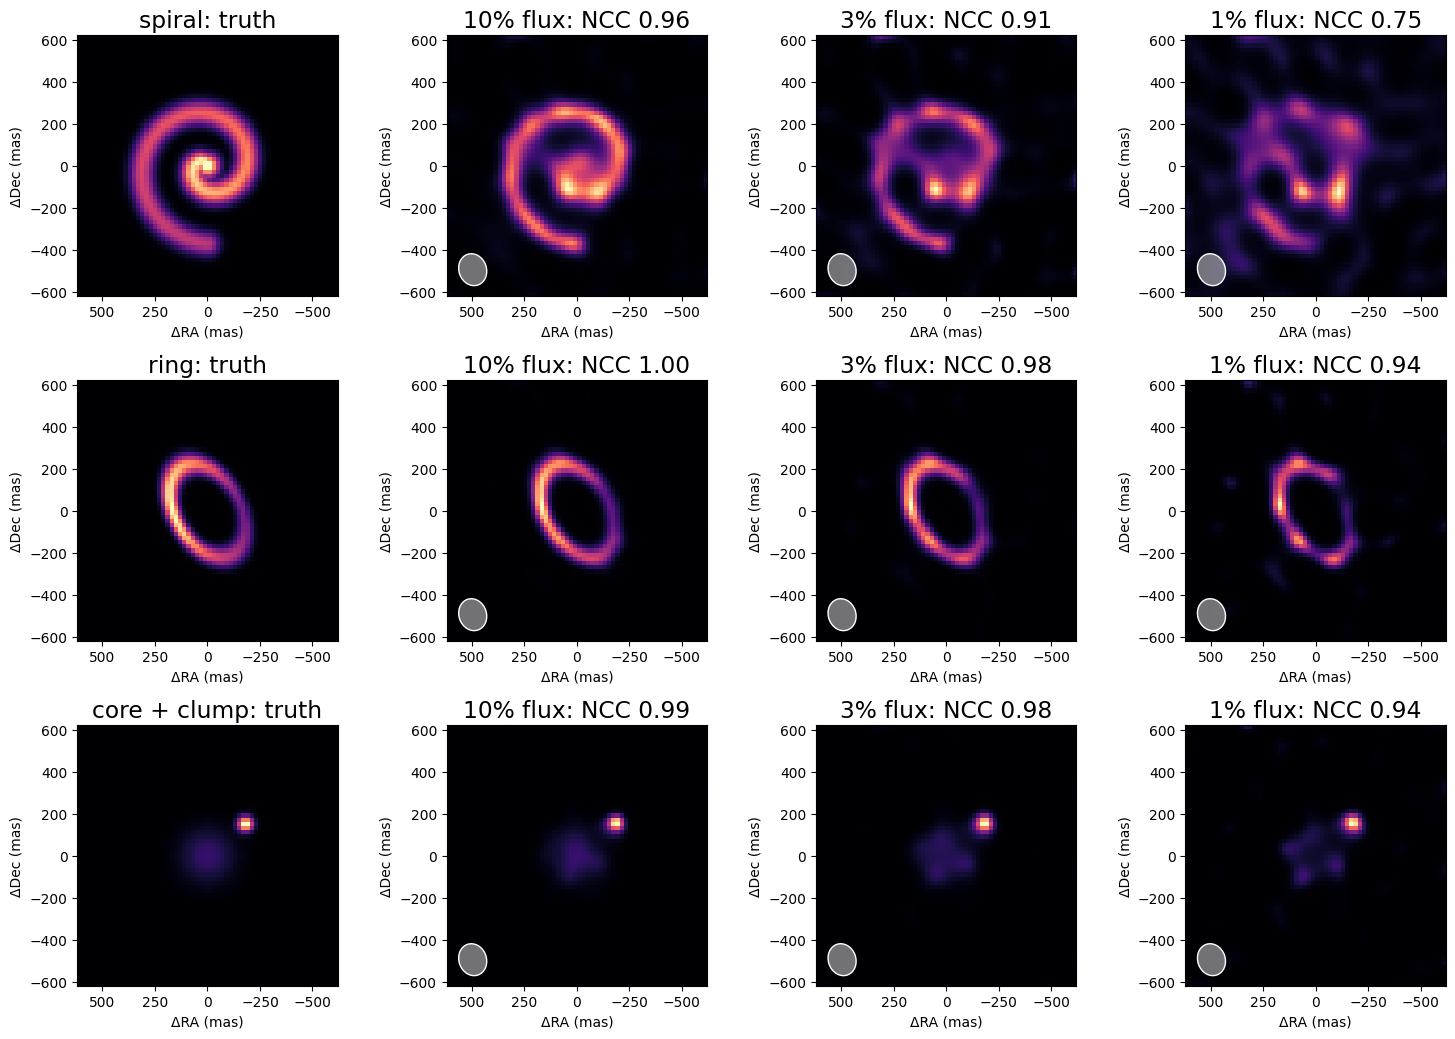

In [3]:
fig, axes = plt.subplots(len(scenes), len(fluxes) + 1, figsize=(15, 10.5))
for row, (name, truth_image) in zip(axes, scenes.items()):
    plot_model(
        Image.from_brightness(truth_image, scale),
        fov_mas=fov,
        npix=npix,
        ax=row[0],
        title=f"{name}: truth",
    )
    for ax, flux in zip(row[1:], fluxes):
        image, score, weight = recovered[name, flux]
        plot_model(
            image,
            fov_mas=fov,
            npix=npix,
            ax=ax,
            title=f"{flux:.0%} flux: NCC {score:.2f}",
            beam=resolution,
        )
plt.tight_layout()
plt.show()

## Where the reconstructions differ from the truth

The signed differences, reconstruction minus truth, for the same cases, on a symmetric colour scale (these are MAP images without uncertainties, so they are not z-scores). Blue is flux the reconstruction misses and red flux it adds; the differences are largest at the sharpest edges of each truth, and grow as the flux falls.

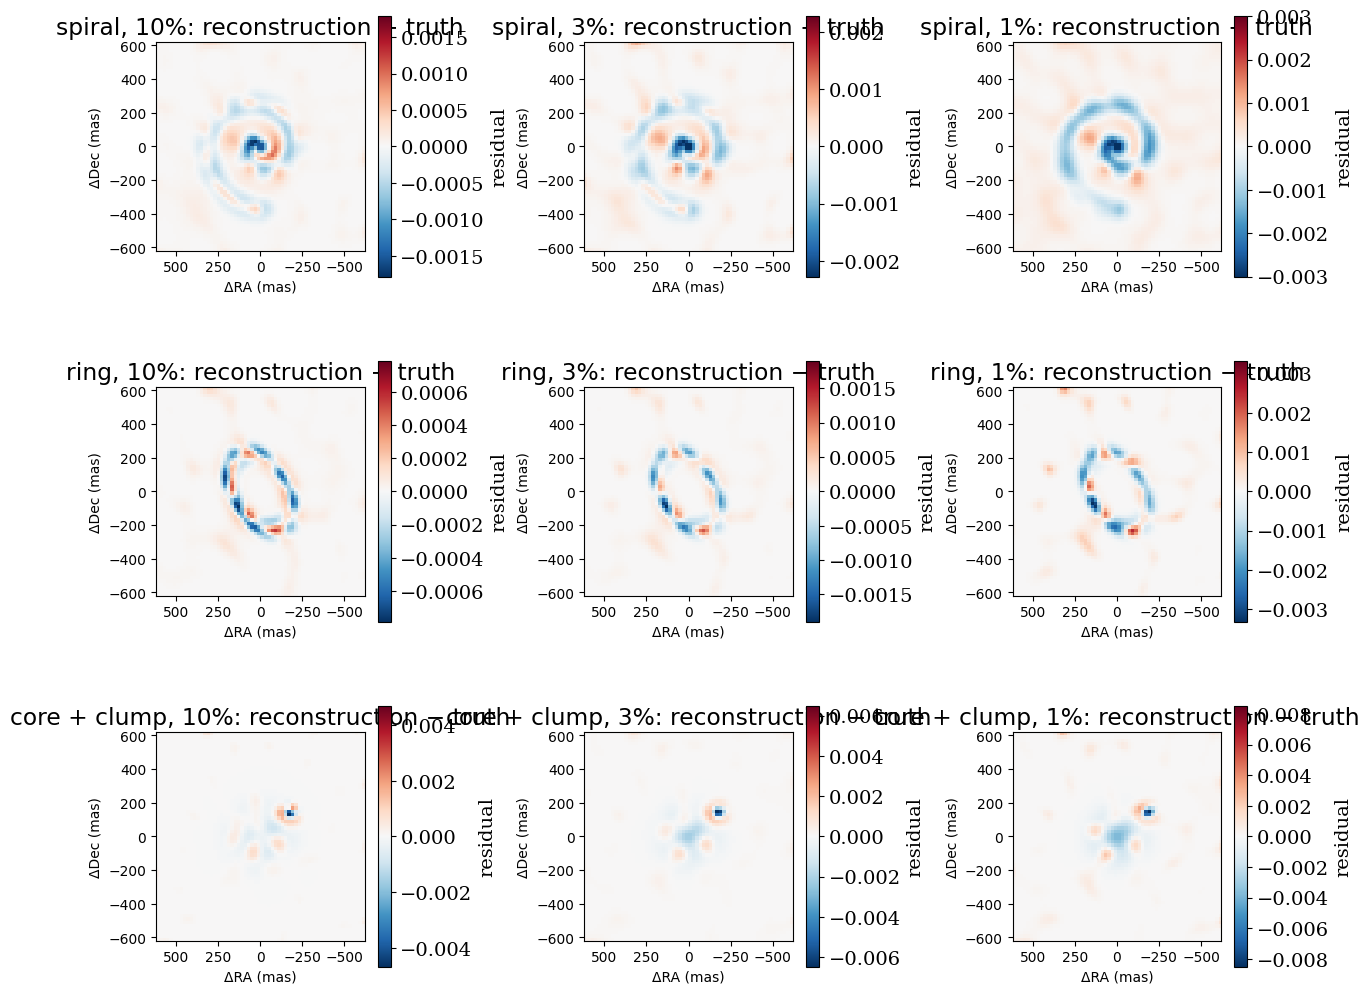

In [4]:
fig, axes = plt.subplots(len(scenes), len(fluxes), figsize=(13, 10.5))
for row, (name, truth_image) in zip(axes, scenes.items()):
    truth = Image.from_brightness(truth_image, scale).render(npix, fov)
    for ax, flux in zip(row, fluxes):
        image = recovered[name, flux][0]
        plot_residual_map(
            image.render(npix, fov) - truth,
            fov_mas=fov,
            ax=ax,
            title=f"{name}, {flux:.0%}: reconstruction − truth",
        )
plt.tight_layout()
plt.show()

## The L-curves behind the choices

At 3% flux, each scene's L-curve is shown with the weight chosen by the discrepancy principle (square). The curves have the expected "L" shape, and the chosen weights sit at the knee, where χ² per point (the dotted line marks one) stops improving.

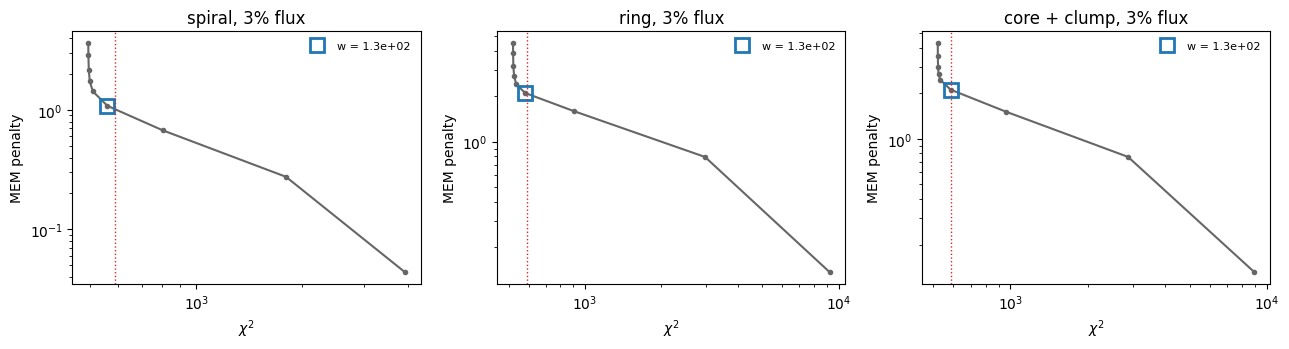

In [5]:
fig, axes = plt.subplots(1, len(scenes), figsize=(13, 3.6))
for ax, name in zip(axes, scenes):
    c = curves[name, 0.03]
    i = int(jnp.argmin(jnp.abs(c.weights - recovered[name, 0.03][2])))
    ax.loglog(c.chi2, c.penalty, "-o", ms=3, color="0.4")
    ax.loglog(
        c.chi2[i],
        c.penalty[i],
        "s",
        ms=10,
        mfc="none",
        mew=2,
        label=f"w = {c.weights[i]:.2g}",
    )
    ax.axvline(template.vis.size, color="C3", ls=":", lw=1)
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set(xlabel=r"$\chi^2$", ylabel="MEM penalty", title=f"{name}, 3% flux")
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Summary

On simulated AMI-like data, with information only in the splodges, maximum entropy at the discrepancy weight recovers scenes three to four beams across very well when the extended emission has 3% or more of the star's flux (normalised cross-correlations of 0.91–0.996), and degrades gracefully at 1%, where fine structure such as the spiral's windings is lost first. To test your own set-up, replace the record with one matching your observation (rotation, wavelength, errors), and the scenes with plausible truths for your target, and check that the reconstructions you would believe are the ones that match.